# Retail Intelligence: Customer Churn

Customer churn is one of the most critical challenges in retail and e-commerce. Even a small improvement in retention can significantly impact revenue and long-term growth.


* Which customers are most likely to churn?
* What behavioral patterns lead to churn?
* Does engagement reduce churn risk?
* Which segments are high-value but at risk?
* How can businesses improve retention strategies?

### 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'font.size': 11
})

COLORS = {
    'red':    '#E24B4A',
    'amber':  '#EF9F27',
    'green':  '#639922',
    'dark_red': '#A32D2D',
    'blue':   '#378ADD',
    'teal':   '#1D9E75',
    'purple': '#7F77DD',
    'gray':   '#888780',
}

In [3]:
df = pd.read_csv('retail_customer_churn.csv')

In [4]:
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 18)


,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,High,1


### 2. Dataset Overview

In [5]:
print("++++++++ Summary ++++++++")
df.info()

++++++++ Summary ++++++++
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   age_group              100000 non-null  str    
 2   gender                 100000 non-null  str    
 3   region                 100000 non-null  str    
 4   customer_segment       100000 non-null  str    
 5   preferred_channel      100000 non-null  str    
 6   purchase_frequency     100000 non-null  int64  
 7   avg_order_value        100000 non-null  float64
 8   total_spent            100000 non-null  float64
 9   recency_days           100000 non-null  int64  
 10  website_visits         100000 non-null  int64  
 11  discount_usage_rate    100000 non-null  float64
 12  email_open_rate        100000 non-null  float64
 13  cart_abandonment_rate  100000 non-null  float64
 14  loyalty_score         

In [6]:
print("++++++++++ DATA TYPES +++++++++")
print(df.dtypes)
print("\n++++ Missing values ++++")
print(df.isnull().sum())
print(df.isnull().sum()/len(df)*100)

++++++++++ DATA TYPES +++++++++
customer_id                  str
age_group                    str
gender                       str
region                       str
customer_segment             str
preferred_channel            str
purchase_frequency         int64
avg_order_value          float64
total_spent              float64
recency_days               int64
website_visits             int64
discount_usage_rate      float64
email_open_rate          float64
cart_abandonment_rate    float64
loyalty_score              int64
engagement_score         float64
churn_risk                   str
churn_flag                 int64
dtype: object

++++ Missing values ++++
customer_id              0
age_group                0
gender                   0
region                   0
customer_segment         0
preferred_channel        0
purchase_frequency       0
avg_order_value          0
total_spent              0
recency_days             0
website_visits           0
discount_usage_rate      0
email_open

In [7]:
print("++++++ Categorical Columns ++++++")

for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    print(f'{col} : {df[col].unique().tolist()}')

++++++ Categorical Columns ++++++
customer_id : ['C000001', 'C000002', 'C000003', 'C000004', 'C000005', 'C000006', 'C000007', 'C000008', 'C000009', 'C000010', 'C000011', 'C000012', 'C000013', 'C000014', 'C000015', 'C000016', 'C000017', 'C000018', 'C000019', 'C000020', 'C000021', 'C000022', 'C000023', 'C000024', 'C000025', 'C000026', 'C000027', 'C000028', 'C000029', 'C000030', 'C000031', 'C000032', 'C000033', 'C000034', 'C000035', 'C000036', 'C000037', 'C000038', 'C000039', 'C000040', 'C000041', 'C000042', 'C000043', 'C000044', 'C000045', 'C000046', 'C000047', 'C000048', 'C000049', 'C000050', 'C000051', 'C000052', 'C000053', 'C000054', 'C000055', 'C000056', 'C000057', 'C000058', 'C000059', 'C000060', 'C000061', 'C000062', 'C000063', 'C000064', 'C000065', 'C000066', 'C000067', 'C000068', 'C000069', 'C000070', 'C000071', 'C000072', 'C000073', 'C000074', 'C000075', 'C000076', 'C000077', 'C000078', 'C000079', 'C000080', 'C000081', 'C000082', 'C000083', 'C000084', 'C000085', 'C000086', 'C000

In [8]:
print (" ++++++ Numerical Columns ++++++")
df.describe().round(2)

 ++++++ Numerical Columns ++++++


,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_flag
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,11.80,209.70,2543.89,182.74,58.52,0.43,0.47,0.45,54.62,51.18,0.46
std,14.37,109.71,3790.84,105.12,78.80,0.22,0.25,0.23,25.96,16.83,0.50
min,1.00,20.03,17.87,1.00,2.00,0.05,0.05,0.05,10.00,10.00,0.00
25%,2.00,114.61,381.32,92.00,10.00,0.24,0.26,0.25,32.00,39.00,0.00
50%,8.00,209.48,1089.18,182.00,29.00,0.43,0.47,0.45,55.00,51.00,0.00
75%,12.00,304.75,2952.17,274.00,71.00,0.61,0.69,0.65,77.00,63.00,1.00
max,60.00,400.00,28444.24,364.00,479.00,0.80,0.90,0.85,99.00,92.00,1.00


### 3. Overall Churn Rate & Risk Distribution

In [9]:
overall_churn = df['churn_flag'].mean()
churn_counts = df['churn_flag'].value_counts()
risk_dist =df['churn_risk'].value_counts()
risk_churn=df.groupby('churn_risk')['churn_flag'].agg(['mean', 'count']).round(3)

print(f'Overall churn rate : {overall_churn : .1%}')
print(f'Churned Customers : { churn_counts[1]:,}')
print(f'Retained Customers : {churn_counts[0]:,}')
print(risk_churn)

Overall churn rate :  46.2%
Churned Customers : 46,224
Retained Customers : 53,776
             mean  count
churn_risk              
High        1.000  32410
Low         0.000  40141
Medium      0.503  27449


#### Visualization: Churn split

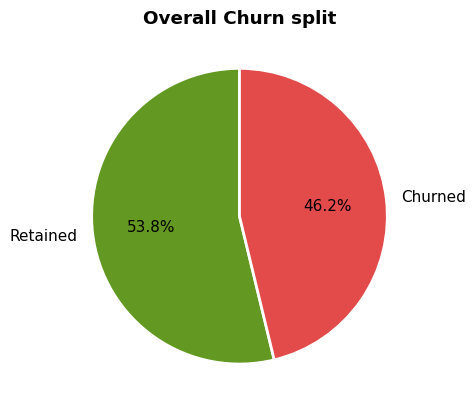

In [63]:
plt.pie([churn_counts[0], churn_counts[1]],
        labels=['Retained', 'Churned'],
        colors=[COLORS['green'], COLORS['red']],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth':2},
        autopct='%1.1f%%')

plt.title('Overall Churn split', fontweight='bold')
plt.gca().set_facecolor('white')
plt.show()

#### Visualization: Risk level distribution

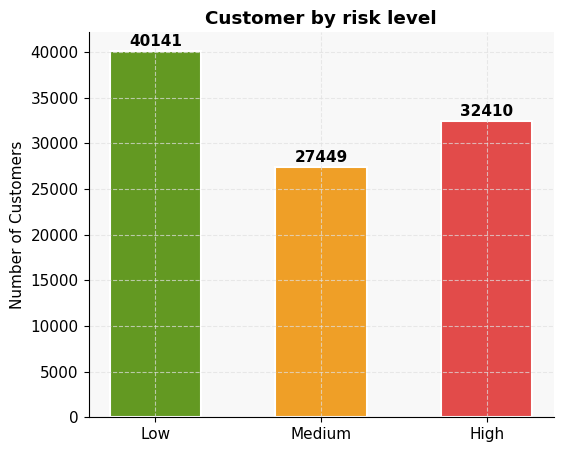

In [64]:
risk_orders = ['Low', 'Medium', 'High']
risk_colors = [COLORS['green'], COLORS['amber'], COLORS['red']]
counts= [risk_dist[r] for r in risk_orders]

plt.figure(figsize=(6,5))
bars=plt.bar(risk_orders, counts, color=risk_colors, edgecolor='White', linewidth=1.5, width=0.55, )
plt.title('Customer by risk level', fontweight='bold')
plt.ylabel("Number of Customers")

# Add percentage labels above each bar
#total = sum(counts)
for bar, count in zip(bars, counts):
    #rate = (count / total) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,   # x position (center of bar)
        bar.get_height() +200,                  # y position (top of bar)
        f'{count:.0f}',                    # formatted percentage
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.show()

#### Visualization: Churn rate by risk

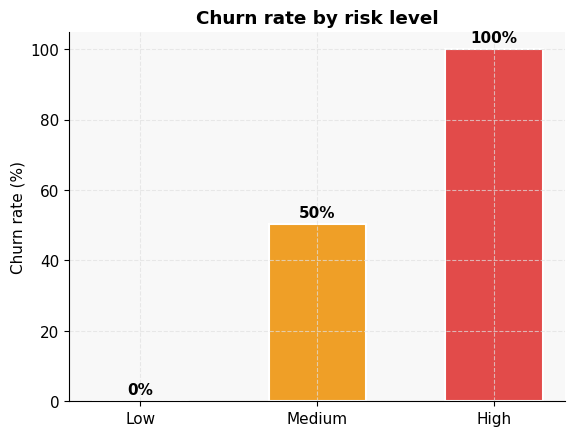

In [65]:
rates=[risk_churn.loc[r, 'mean']* 100 for r in risk_orders]

bars= plt.bar(risk_orders, rates, color=risk_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, rates in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,   # x position (center of bar)
        bar.get_height() + 1,                  # y position (top of bar)
        f'{rates:.0f}%',                    # formatted percentage
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.title('Churn rate by risk level', fontweight='bold')
plt.ylabel('Churn rate (%)')
plt.show()

## 4.Questions

### Question 1— Which Customers Are Most Likely to Churn?

In [13]:
# Churn rates across categorical dimensions
dimensions = {
    'customer_segment': 'Customer Segment',
    'age_group':        'Age Group',
    'region':           'Region',
    'preferred_channel':'Preferred Channel',
    'gender':           'Gender',
}

for col, label in dimensions.items():
    result=df.groupby(col)['churn_flag'].agg(['mean', 'count'])
    result['churn_rate']=(result['mean']*100).round(1)
    print(f'\n +++++{label}+++++')
    print(result[['churn_rate', 'count']].to_string())


 +++++Customer Segment+++++
                  churn_rate  count
customer_segment                   
Loyal                   45.9  24875
New                     46.3  25113
Returning               46.0  25106
VIP                     46.7  24906

 +++++Age Group+++++
           churn_rate  count
age_group                   
18-24            46.2  19987
25-34            45.9  19929
35-44            46.4  20109
45-54            46.1  20093
55+              46.5  19882

 +++++Region+++++
         churn_rate  count
region                    
Central        46.5  20012
East           46.4  20240
North          46.3  20035
South          45.5  19674
West           46.5  20039

 +++++Preferred Channel+++++
                   churn_rate  count
preferred_channel                   
In-Store                 46.3  33303
Mobile App               45.7  33267
Online                   46.7  33430

 +++++Gender+++++
        churn_rate  count
gender                   
Female        46.3  33367
Male      

#### Visualization: Churn rate by Customer Segment

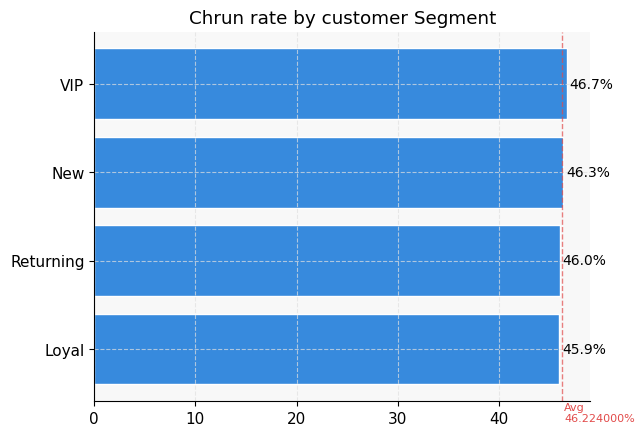

In [14]:
data = (df.groupby('customer_segment')['churn_flag'].mean()*100).sort_values(ascending=True)
bars=plt.barh(data.index, data.values, color=COLORS['blue'], edgecolor='white', linewidth=1)
plt.title('Chrun rate by customer Segment')

for bar, val in zip(bars, data.values):
    plt.text(
        val + 0.3, bar.get_y() + bar.get_height()/2,  # x position (center of bar)                # y position (top of bar)
        f'{val:.1f}%',                    # formatted percentage
        va='center',fontsize=10
    )
plt.axvline(overall_churn*100, color=COLORS['red'], linestyle= '--', alpha=0.7, linewidth=1)
plt.text(overall_churn*100+0.2, -0.6, f'Avg\n{overall_churn:1%}', color=COLORS['red'], fontsize=8, va='top')

plt.show()

#### Visualizaton: Churn rate by Customer age group

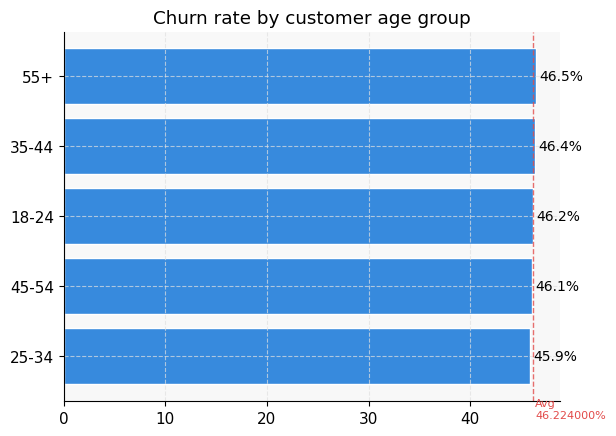

In [15]:
data=(df.groupby('age_group')['churn_flag'].mean()*100).sort_values(ascending=True)
bars=plt.barh(data.index, data.values, color=COLORS['blue'], edgecolor='white', linewidth=1)
plt.title('Churn rate by customer age group')

for bar, val in zip(bars,data.values):
    plt.text(
        val + 0.3, bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center', fontsize=10
    )

plt.axvline(overall_churn*100, color=COLORS['red'], linestyle='--', alpha=0.8, linewidth=1)
plt.text(overall_churn*100+0.2, -0.6, f'Avg\n{overall_churn:1%}', color=COLORS['red'], fontsize=8, va='top')
plt.show()

#### Visualization: Churn rate by Customer region

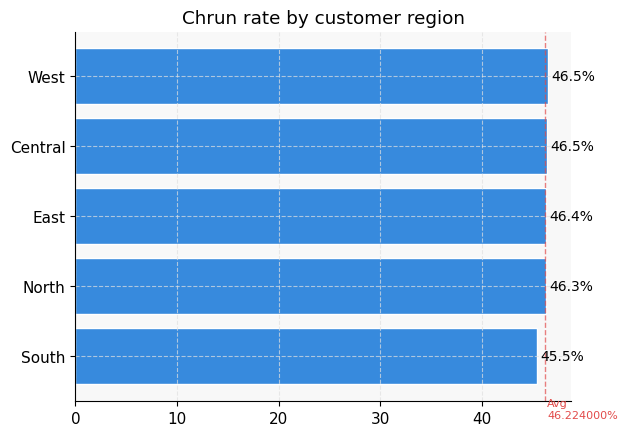

In [16]:
data = (df.groupby('region')['churn_flag'].mean()*100).sort_values(ascending=True)
bars=plt.barh(data.index, data.values, color=COLORS['blue'], edgecolor='white', linewidth=1)
plt.title('Chrun rate by customer region')

for bar, val in zip(bars, data.values):
    plt.text(
        val + 0.3, bar.get_y() + bar.get_height()/2,  # x position (center of bar)                # y position (top of bar)
        f'{val:.1f}%',                    # formatted percentage
        va='center',fontsize=10
    )
plt.axvline(overall_churn*100, color=COLORS['red'], linestyle= '--', alpha=0.7, linewidth=1)
plt.text(overall_churn*100+0.2, -0.6, f'Avg\n{overall_churn:1%}', color=COLORS['red'], fontsize=8, va='top')

plt.show()

#### Visualization: Churn rate by Customer channel

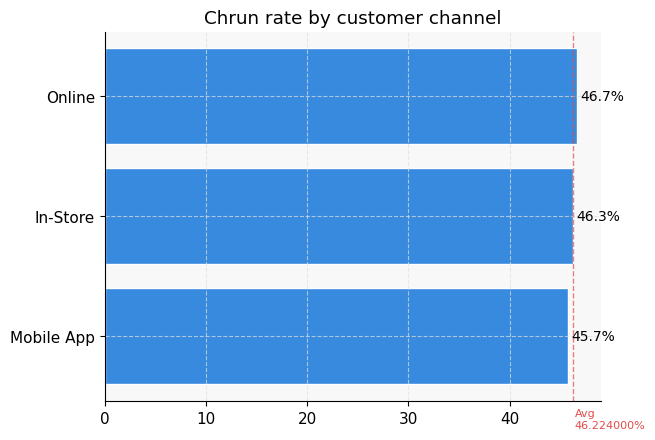

In [17]:
data = (df.groupby('preferred_channel')['churn_flag'].mean()*100).sort_values(ascending=True)
bars=plt.barh(data.index, data.values, color=COLORS['blue'], edgecolor='white', linewidth=1)
plt.title('Chrun rate by customer channel')

for bar, val in zip(bars, data.values):
    plt.text(
        val + 0.3, bar.get_y() + bar.get_height()/2,  # x position (center of bar)                # y position (top of bar)
        f'{val:.1f}%',                    # formatted percentage
        va='center',fontsize=10
    )
plt.axvline(overall_churn*100, color=COLORS['red'], linestyle= '--', alpha=0.7, linewidth=1)
plt.text(overall_churn*100+0.2, -0.6, f'Avg\n{overall_churn:1%}', color=COLORS['red'], fontsize=8, va='top')

plt.show()

* Key insight: Churn is remarkably uniform across segments, age groups, regions, and channels.
* The problem is behavioural, not demographic

### Question 2 — What Behavioral Patterns Lead to Churn?

In [18]:
#Recency buckets

df['recency_bucket']=pd.cut(df['recency_days'],bins=[0,30,90,180,365], labels=['< 30 days', '30-90 days', '90-180 days', '180-365 days'])

recency_churn = df.groupby('recency_bucket', observed=True)['churn_flag'].agg(['mean', 'count'])
recency_churn['churn_rate'] = (recency_churn['mean']*100).round(1)
print('Churn rate by recency bucket:')
print(recency_churn[['churn_rate', 'count']])


Churn rate by recency bucket:
                churn_rate  count
recency_bucket                   
< 30 days              0.0   8182
30-90 days             0.9  16437
90-180 days           17.9  24807
180-365 days          82.3  50574


In [19]:
# Cart abandonment quartiles
df['cart_q'] = pd.qcut(df['cart_abandonment_rate'], 4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])

cart_churn=(df.groupby('cart_q', observed=True)['churn_flag'].mean()*100).round(1)
print('Churn rate by cart abandonment quartile:')
print(cart_churn)

# Loyalty score quartiles

df['loyalty_q']=pd.qcut(df['loyalty_score'],4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])

loyalty_churn=(df.groupby('loyalty_q', observed=True)['churn_flag'].mean()*100).round(1)
print('\nChurn rate by loyalty score quartile:')
print(loyalty_churn)

# Email open rate quartiles

df['email_q']=pd.qcut(df['email_open_rate'],4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
email_churn=(df.groupby('email_q', observed=True)['churn_flag'].mean()*100).round(1)
print('\nChurn rate by email open rate quartile:')
print(email_churn)

Churn rate by cart abandonment quartile:
cart_q
Q1 Low     31.4
Q2         41.7
Q3         51.4
Q4 High    61.0
Name: churn_flag, dtype: float64

Churn rate by loyalty score quartile:
loyalty_q
Q1 Low     57.4
Q2         50.3
Q3         41.9
Q4 High    34.8
Name: churn_flag, dtype: float64

Churn rate by email open rate quartile:
email_q
Q1 Low     45.8
Q2         46.4
Q3         46.2
Q4 High    46.5
Name: churn_flag, dtype: float64


#### Visualization: Recency

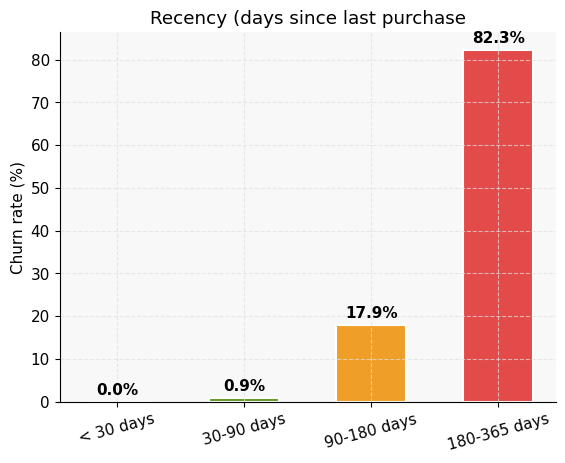

In [20]:
bucket_colors = [COLORS['green'], COLORS['green'], COLORS['amber'], COLORS['red']]
bars = plt.bar(recency_churn.index, recency_churn['churn_rate'], color=bucket_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, recency_churn['churn_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() +1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    

plt.title('Recency (days since last purchase')
plt.ylabel('Churn rate (%)')
plt.tick_params(axis='x', rotation=15)

plt.show()

#### Visualization: Cart abandonment

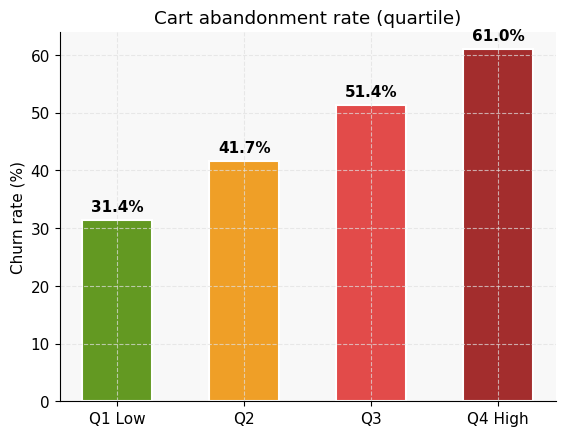

In [21]:
cart_colors = [COLORS['green'], COLORS['amber'], COLORS['red'], COLORS['dark_red']]

bars= plt.bar(cart_churn.index, cart_churn.values, color=cart_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, cart_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    

plt.title('Cart abandonment rate (quartile)')
plt.ylabel('Churn rate (%)')

plt.show()

#### Visualization: Loyalty score

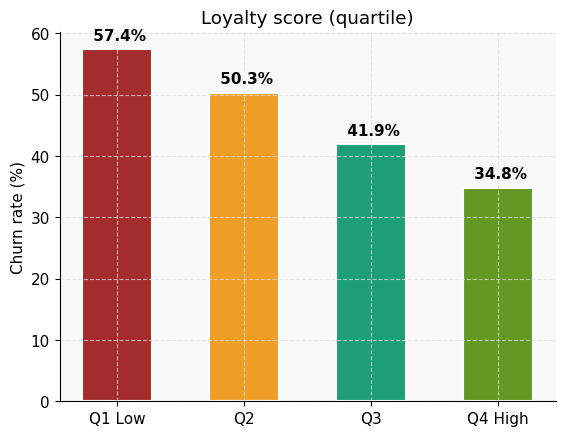

In [22]:
loyalty_colors = [COLORS['dark_red'], COLORS['amber'], COLORS['teal'], COLORS['green']]

bars=plt.bar(loyalty_churn.index, loyalty_churn.values, color=loyalty_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, loyalty_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val: .1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
plt.title('Loyalty score (quartile)')
plt.ylabel('Churn rate (%)')
plt.show()

### Question 3 — Does Engagement Reduce Churn Risk?

#### Full numerical comparison: churned vs retained

In [23]:
numeric_cols=[
    'recency_days', 'purchase_frequency', 'avg_order_value', 'total_spent',
    'website_visits', 'discount_usage_rate', 'email_open_rate',
    'cart_abandonment_rate', 'loyalty_score', 'engagement_score'
]


comparison = df.groupby('churn_flag')[numeric_cols].mean().round(3).T
comparison.columns = ['Retained', 'Churned']
comparison['Difference'] = comparison['Churned']- comparison['Retained']
comparison['% Change'] = ((comparison['Difference'] / comparison['Retained']) * 100).round(1)
print('Churned vs Retained — Mean Comparison:')
print(comparison.to_string())

Churned vs Retained — Mean Comparison:
                       Retained   Churned  Difference  % Change
recency_days            107.302   270.504     163.202     152.1
purchase_frequency       12.466    11.030      -1.436     -11.5
avg_order_value         210.145   209.192      -0.953      -0.5
total_spent            2692.557  2370.936    -321.621     -11.9
website_visits           61.746    54.777      -6.969     -11.3
discount_usage_rate       0.426     0.427       0.001       0.2
email_open_rate           0.474     0.475       0.001       0.2
cart_abandonment_rate     0.402     0.508       0.106      26.4
loyalty_score            58.835    49.710      -9.125     -15.5
engagement_score         53.586    48.374      -5.212      -9.7


#### Engagement score quartile analysis

In [24]:
df['engagement_q'] = pd.qcut( df['engagement_score'], 4, labels= ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

engagement_churn = (df.groupby('engagement_q', observed=True)['churn_flag'].mean() *100).round(1)
print('Churn rate by engagement score quartile:')
print(engagement_churn)

Churn rate by engagement score quartile:
engagement_q
Q1 (low)     56.1
Q2           48.6
Q3           43.9
Q4 (high)    36.2
Name: churn_flag, dtype: float64


#### Website visits quartile

In [25]:
df['visits_q'] = pd.qcut(df['website_visits'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

visits_churn = (df.groupby('visits_q')['churn_flag'].mean() * 100).round(1)

print('\nChurn rate by website visits quartile:')
print(visits_churn)


Churn rate by website visits quartile:
visits_q
Q1 (low)     48.4
Q2           47.2
Q3           46.4
Q4 (high)    42.9
Name: churn_flag, dtype: float64


#### Visualization: side-by-side bar for key metrics

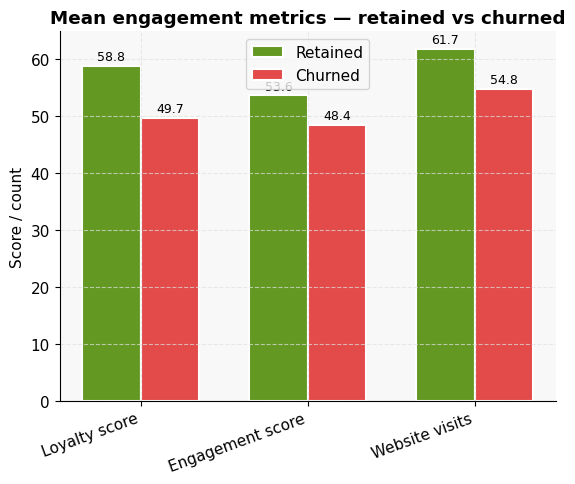

In [26]:
metrics= ['loyalty_score', 'engagement_score', 'website_visits']
labels = ['Loyalty score', 'Engagement score', 'Website visits']

retained_vals = [df[df['churn_flag']==0][m].mean() for m in metrics]
churned_vals = [df[df['churn_flag']==1][m].mean() for m in metrics]

x=np.arange(len(labels))
w=0.35

bar1=plt.bar(x- w/2, retained_vals, w, label="Retained", color=COLORS['green'], edgecolor='white', linewidth=1.5)
bar2=plt.bar(x+ w/2, churned_vals, w, label='Churned', color=COLORS['red'], edgecolor='white', linewidth=1.5)

for bar in [*bar1,*bar2]:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
    
plt.xticks(x, labels, rotation=20, ha='right')
plt.title('Mean engagement metrics — retained vs churned', fontweight='bold')
plt.ylabel('Score / count')
plt.legend()
plt.show()



#### Visualization: Engagement quartile churn rate

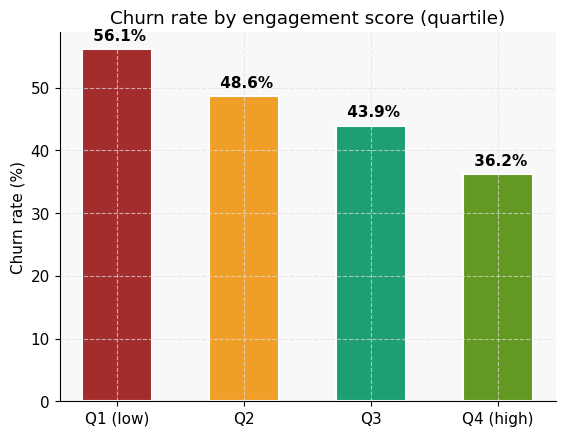

In [27]:
eng_colors =[COLORS['dark_red'], COLORS['amber'], COLORS['teal'], COLORS['green']]
bars = plt.bar(engagement_churn.index, engagement_churn.values, color=eng_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, engagement_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val: .1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    

plt.title('Churn rate by engagement score (quartile)')
plt.ylabel('Churn rate (%)')

plt.show()

#### Non-signals: email open rate & discount usage

In [28]:
chruned = df[df['churn_flag']==1]
retained =df[df['churn_flag']==0]

print('=== Signals That Do NOT Predict Churn ===')

for col in ['email_open_rate','discount_usage_rate','avg_order_value']:
    diff=chruned[col].mean()-retained[col].mean()
    
    print(f'{col}: churned={chruned[col].mean(): .3f}',
      f'retained={retained[col].mean():.3f}, diff={diff:+.4f} (negligible)')

=== Signals That Do NOT Predict Churn ===
email_open_rate: churned= 0.475 retained=0.474, diff=+0.0012 (negligible)
discount_usage_rate: churned= 0.427 retained=0.426, diff=+0.0008 (negligible)
avg_order_value: churned= 209.192 retained=210.145, diff=-0.9528 (negligible)


### Question 4 — High-Value Customers at Risk

#### Cross-tab: segment × risk level

In [29]:
segment_risk = df.groupby(['customer_segment', 'churn_risk']).size().unstack(fill_value=0)
segment_risk['total']=segment_risk.sum(axis=1)

for col in ['High', 'Medium', 'Low']:
    segment_risk[f'{col}_pct']=(segment_risk[col] / segment_risk['total']*100).round(1)
print('Customer count by segment and risk level:')
print(segment_risk)


Customer count by segment and risk level:
churn_risk        High    Low  Medium  total  High_pct  Medium_pct  Low_pct
customer_segment                                                           
Loyal             7982   9990    6903  24875      32.1        27.8     40.2
New               8137  10089    6887  25113      32.4        27.4     40.2
Returning         8147  10169    6790  25106      32.5        27.0     40.5
VIP               8144   9893    6869  24906      32.7        27.6     39.7


#### High-value at-risk profiles

In [30]:
for segment in ['VIP', "Loyal"]:
    at_risk= df[(df['customer_segment']==segment) & (df['churn_risk'] == 'High')]
    print(f'+++ {segment} — High Risk +++')
    print(f'  Count:              {len(at_risk):,}')
    print(f'  Avg total spent:    ${at_risk["total_spent"].mean():,.2f}')
    print(f'  Avg recency (days): {at_risk["recency_days"].mean():.1f}')
    print(f'  Avg loyalty score:  {at_risk["loyalty_score"].mean():.1f}')
    print(f'  Avg cart abandon:   {at_risk["cart_abandonment_rate"].mean():.2f}')
    print()

+++ VIP — High Risk +++
  Count:              8,144
  Avg total spent:    $2,260.76
  Avg recency (days): 292.2
  Avg loyalty score:  47.9
  Avg cart abandon:   0.53

+++ Loyal — High Risk +++
  Count:              7,982
  Avg total spent:    $2,357.68
  Avg recency (days): 291.6
  Avg loyalty score:  47.8
  Avg cart abandon:   0.53



#### Stacked bar: segment × risk

In [31]:
segments = ['VIP', 'Loyal', 'Returning', 'New']
risk_levels = ['High', 'Medium', 'Low']
risk_colors_map = {'High': COLORS['red'], 'Medium': COLORS['amber'], 'Low': COLORS['green']}



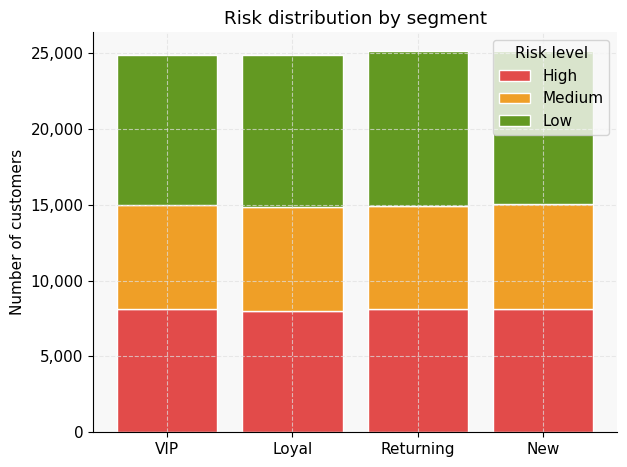

In [32]:
bottom = np.zeros(len(segments))

for risk in risk_levels:
    vals = [segment_risk.loc[s,risk] for s in segments]
    plt.bar(segments, vals, bottom=bottom, label=risk,
            color=risk_colors_map[risk], edgecolor='white', linewidth=1)
    
    bottom+= np.array(vals)


plt.title('Risk distribution by segment')
plt.ylabel('Number of customers')

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Risk level', loc='upper right')
plt.tight_layout()
plt.show()

#### VIP spend distribution: high-risk vs others

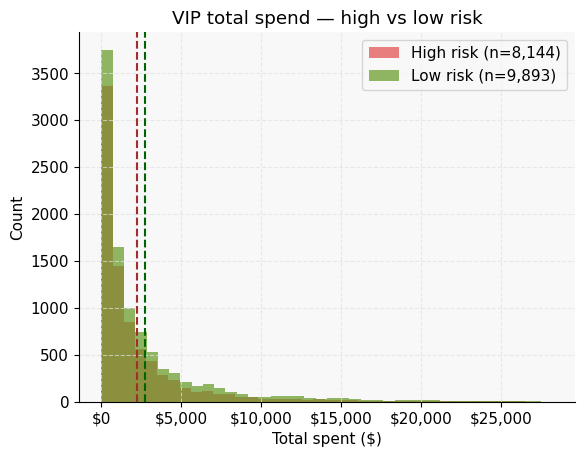

In [33]:
vip = df[df['customer_segment'] == 'VIP']
vip_hr = vip[vip['churn_risk'] =='High']['total_spent']
vip_safe = vip[vip['churn_risk'] == 'Low']['total_spent']
plt.hist(vip_hr, bins=40, alpha=0.7, color=COLORS['red'],   label=f'High risk (n={len(vip_hr):,})')
plt.hist(vip_safe, bins=40, alpha=0.7, color=COLORS['green'], label=f'Low risk (n={len(vip_safe):,})')
plt.axvline(vip_hr.mean(), color=COLORS['dark_red'], linestyle='--', linewidth=1.5)
plt.axvline(vip_safe.mean(), color='darkgreen', linestyle='--', linewidth=1.5)
plt.title('VIP total spend — high vs low risk')
plt.xlabel('Total spent ($)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.legend()
plt.show()

#### High-risk avg spend by segment

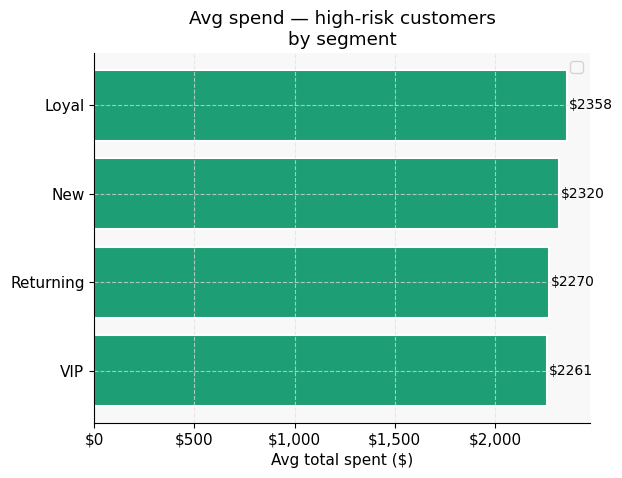

In [34]:
high_risk_spend = (
    df[df['churn_risk']=='High']
    .groupby('customer_segment')['total_spent'].mean()
    .sort_values(ascending=True)
)

bars = plt.barh(high_risk_spend.index, high_risk_spend.values,
                color=COLORS['teal'], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, high_risk_spend.values):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2,
             f'${val:.0f}', va='center', fontsize=10)
    
plt.title('Avg spend — high-risk customers\nby segment')
plt.xlabel('Avg total spent ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.legend()
plt.show()

#### Question 5 — Retention Strategy Insights

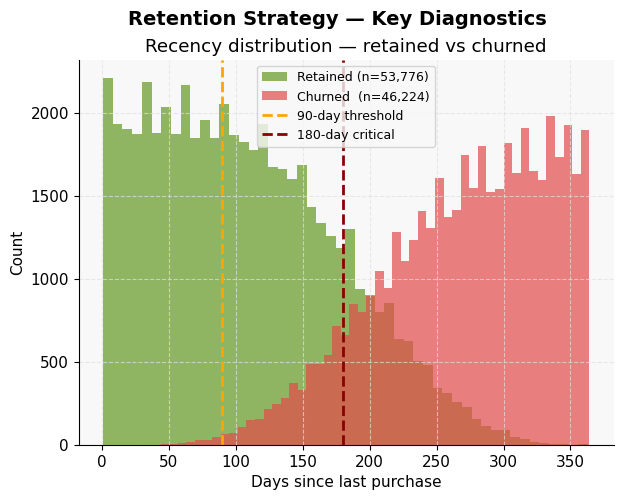

In [61]:
# Recency distribution by churn flag
fig, axes = plt.subplots(1, figsize=(6.9, 5))
fig.suptitle('Retention Strategy — Key Diagnostics', fontsize=14, fontweight='bold')

# Recency distribution
ax = axes
ax.hist(retained['recency_days'], bins=50, alpha=0.7, color=COLORS['green'],
        label=f'Retained (n={len(retained):,})')
ax.hist(churned['recency_days'],  bins=50, alpha=0.7, color=COLORS['red'],
        label=f'Churned  (n={len(churned):,})')
ax.axvline(90,  color='orange', linestyle='--', linewidth=2, label='90-day threshold')
ax.axvline(180, color='darkred', linestyle='--', linewidth=2, label='180-day critical')
ax.set_title('Recency distribution — retained vs churned')
ax.set_xlabel('Days since last purchase')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.show()

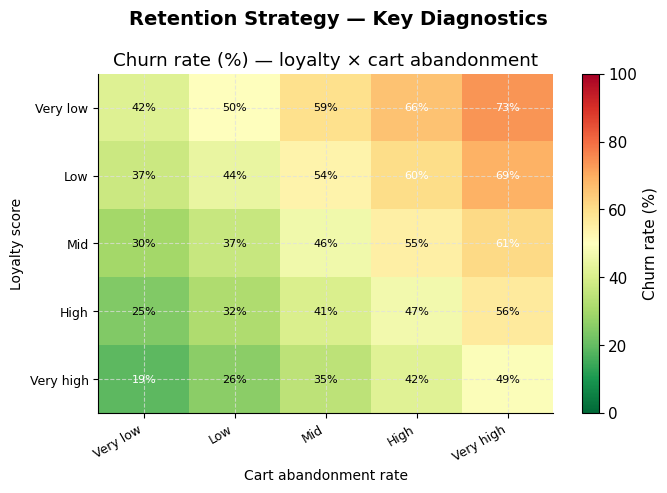

In [60]:
# Cart abandonment × loyalty heatmap
fig, axes = plt.subplots(1, figsize=(6.9, 5))
fig.suptitle('Retention Strategy — Key Diagnostics', fontsize=14, fontweight='bold')
ax = axes
df['cart_decile'] = pd.qcut(df['cart_abandonment_rate'], 5,
                            labels=['Very low','Low','Mid','High','Very high'])
df['loyalty_decile'] = pd.qcut(df['loyalty_score'], 5,
                                labels=['Very low','Low','Mid','High','Very high'])

heatmap_data = df.groupby(['loyalty_decile', 'cart_decile'], observed=True)['churn_flag'].mean() * 100
heatmap_pivot = heatmap_data.unstack('cart_decile')

im = ax.imshow(heatmap_pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(heatmap_pivot.columns)))
ax.set_xticklabels(heatmap_pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index, fontsize=9)
ax.set_xlabel('Cart abandonment rate', fontsize=10)
ax.set_ylabel('Loyalty score', fontsize=10)
ax.set_title('Churn rate (%) — loyalty × cart abandonment')

for i in range(len(heatmap_pivot.index)):
    for j in range(len(heatmap_pivot.columns)):
        val = heatmap_pivot.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8,
                color='white' if val > 60 or val < 20 else 'black')

plt.colorbar(im, ax=ax, label='Churn rate (%)')
plt.tight_layout()
plt.show()

### Summary & Actionable Recommendations

In [62]:
print('=' * 65)
print('RETAIL CUSTOMER CHURN — KEY FINDINGS')
print('=' * 65)

print(f"""
DATASET
  Total customers : {len(df):,}
  Churned         : {churn_counts[1]:,} ({churn_counts[1]/len(df):.1%})
  High-risk       : {risk_dist['High']:,} (all will churn)
  Medium-risk     : {risk_dist['Medium']:,} (50% churn rate)

TOP SIGNALS (strongest → weakest)
  1. Recency       180–365d inactive = 82.3% churn (vs 0% for <30d)
  2. Cart abandon  Q4 vs Q1 = 61% vs 31% churn (30pp gap)
  3. Loyalty score Q1 vs Q4 = 57% vs 35% churn (22pp gap)
  4. Engagement    Churned avg 48.4 vs retained 53.6 (−5.2)
  5. Site visits   Churned avg 54.8 vs retained 61.7 (−6.9)

NON-SIGNALS (negligible difference)
  - Email open rate   : virtually identical across churned/retained
  - Discount usage    : virtually identical across churned/retained
  - Avg order value   : virtually identical ($209 vs $210)
  - Channel           : all ~46% churn (In-Store / Mobile / Online)
  - Age group         : all ~46% churn (18-24 through 55+)
  - Customer segment  : all ~46% churn (VIP / Loyal / New / Returning)

HIGH-VALUE AT RISK
  VIP high-risk   : {len(df[(df['customer_segment']=='VIP') & (df['churn_risk']=='High')]):,} customers
                    avg ${df[(df['customer_segment']=='VIP') & (df['churn_risk']=='High')]['total_spent'].mean():,.0f} spend
                    avg {df[(df['customer_segment']=='VIP') & (df['churn_risk']=='High')]['recency_days'].mean():.0f} days inactive
  Loyal high-risk : {len(df[(df['customer_segment']=='Loyal') & (df['churn_risk']=='High')]):,} customers
                    avg ${df[(df['customer_segment']=='Loyal') & (df['churn_risk']=='High')]['total_spent'].mean():,.0f} spend

RETENTION ACTIONS
  1. Win-back at 90 days    — churn risk jumps from 1% → 18% here
  2. Cart recovery flows    — target top abandonment quartile (61% at risk)
  3. Loyalty programme push — low-loyalty customers churn at 57%
  4. VIP personal outreach  — 8,144 customers, highest revenue at stake
  5. Engagement monitoring  — 2-week visit drop is an early warning sign
  6. Do NOT rely on email   — open rate does not correlate with retention
""")
print('=' * 65)

RETAIL CUSTOMER CHURN — KEY FINDINGS

DATASET
  Total customers : 100,000
  Churned         : 46,224 (46.2%)
  High-risk       : 32,410 (all will churn)
  Medium-risk     : 27,449 (50% churn rate)

TOP SIGNALS (strongest → weakest)
  1. Recency       180–365d inactive = 82.3% churn (vs 0% for <30d)
  2. Cart abandon  Q4 vs Q1 = 61% vs 31% churn (30pp gap)
  3. Loyalty score Q1 vs Q4 = 57% vs 35% churn (22pp gap)
  4. Engagement    Churned avg 48.4 vs retained 53.6 (−5.2)
  5. Site visits   Churned avg 54.8 vs retained 61.7 (−6.9)

NON-SIGNALS (negligible difference)
  - Email open rate   : virtually identical across churned/retained
  - Discount usage    : virtually identical across churned/retained
  - Avg order value   : virtually identical ($209 vs $210)
  - Channel           : all ~46% churn (In-Store / Mobile / Online)
  - Age group         : all ~46% churn (18-24 through 55+)
  - Customer segment  : all ~46% churn (VIP / Loyal / New / Returning)

HIGH-VALUE AT RISK
  VIP high-ris